In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
#Считываю данные
df = pd.read_csv('data/CC GENERAL.csv')

In [3]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [4]:
#1 Проверяю данные
#1.1 Общая информация о данных
print(df.shape)       # Сколько строк и столбцов
print(df.info())      # Типы данных и наличие пропусков

(8950, 18)
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
# 1.1. Пропуски (NaN)
print("\n--- Пропуски в столбцах ---")
print(df.isnull().sum())


--- Пропуски в столбцах ---
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [6]:
# 1.2. Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"\n--- Дубликаты: {duplicates} ---")


--- Дубликаты: 0 ---


Итого:
1. CUST_ID - удаляем, не несет нужной информации
2. Пропуски в CREDIT_LIMIT (1 строка), MINIMUM_PAYMENTS (313) - заменяем медианой
3. Дубликатов нет 

In [7]:
df = df.drop(columns=["CUST_ID"])
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [8]:
#2 Масштабируем, потому что PCA чувствителен к масштабу признаков

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)  # numpy array

# Преобразуем обратно в DataFrame с сохранением структуры
df_scaled = pd.DataFrame(
    df_scaled_array,
    columns=df.columns, 
    index=df.index      
)



In [9]:
from sklearn.cluster import KMeans

In [10]:
def distance_by_n(x,n):
    model = KMeans(n_clusters = n, random_state=42, n_init=10)
    model.fit(x)
    return model.inertia_

In [11]:
#Я не знаю сколько я у меня кластеров, поэтому скоры для разных вариантов  
score = []
for i in range(1,11):
    score.append(distance_by_n(df_scaled,i))    
    

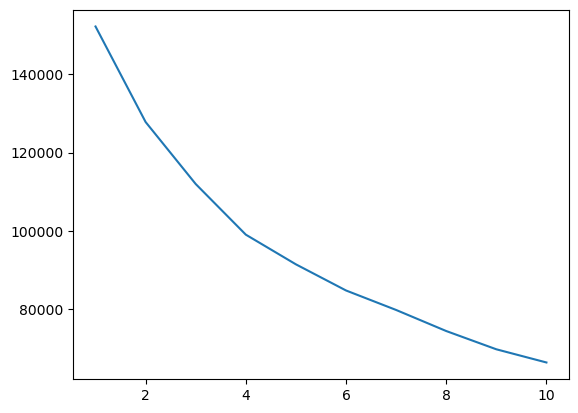

In [12]:
import matplotlib.pyplot as plt
#показываю на графике
plt.plot(range(1,11),score)

На графике нет чёткого "локтя"
k=1→2: резкое падение
k=2→3: ещё заметное падение
k=3→4: уменьшение замедляется
k=4+: кривая постепенно выравнивается

Предполагаю что нужно использовать k=3 или 4


K = 3

Размер кластеров:
0    1275
1    6114
2    1561
Name: count, dtype: int64

Профили кластеров (ключевые признаки):
       BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS
label                                            
0         0.30       1.49          0.87      0.81
1        -0.36      -0.24         -0.34     -0.29
2         1.18      -0.29          0.61      0.46


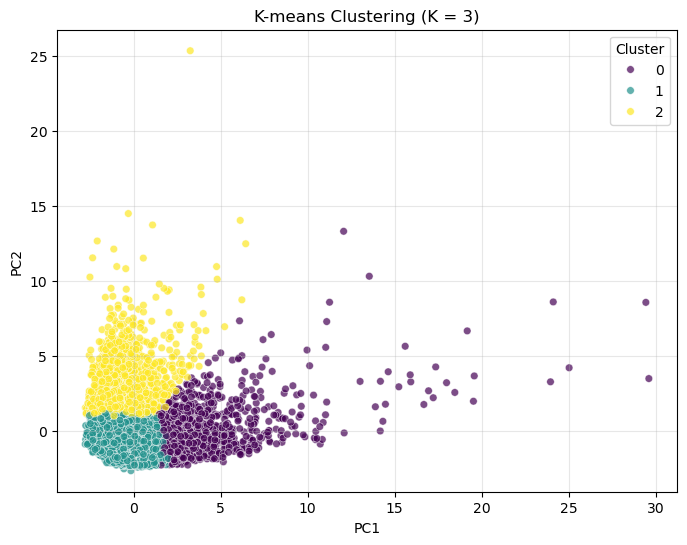


K = 4

Размер кластеров:
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64

Профили кластеров (ключевые признаки):
       BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS
label                                            
0        -0.27      -0.34         -0.33     -0.26
1         0.95       3.13          1.43      1.92
2         1.46      -0.23          0.84      0.60
3        -0.32       0.11         -0.08     -0.14


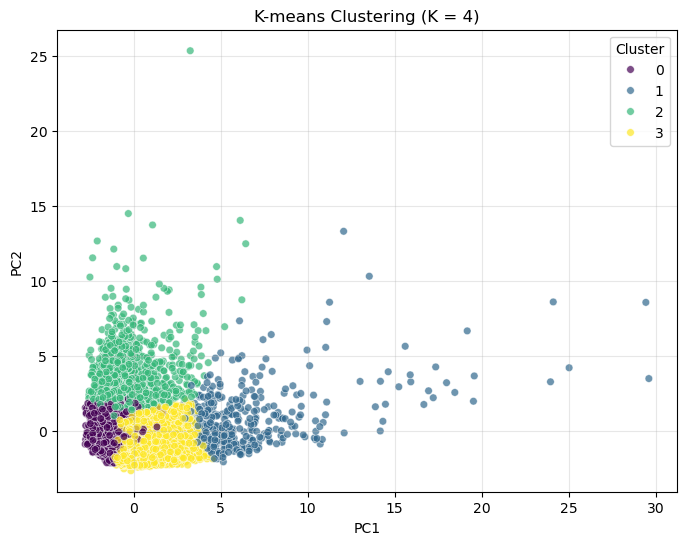


K = 5

Размер кластеров:
0    3910
1    1385
2      85
3    2415
4    1155
Name: count, dtype: int64

Профили кластеров (ключевые признаки):
       BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS
label                                            
0        -0.25      -0.34         -0.32     -0.25
1         0.16       0.90          0.69      0.36
2         1.42       6.97          2.19      4.78
3        -0.44      -0.10         -0.36     -0.28
4         1.46      -0.24          0.83      0.64


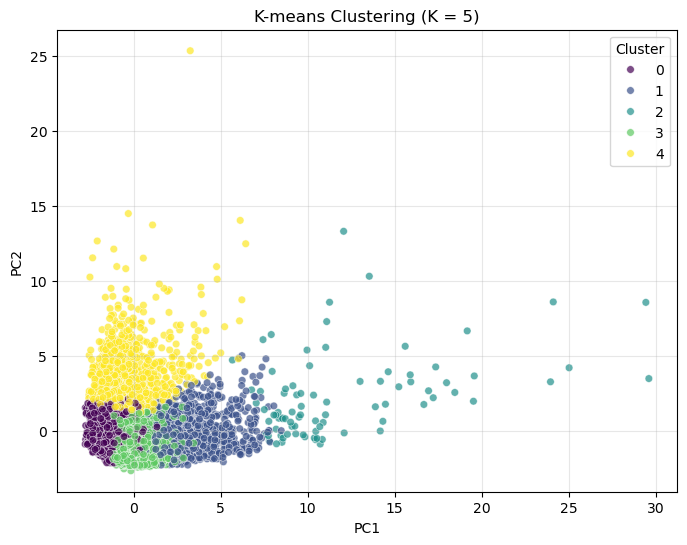

In [13]:
model = PCA(2)
X_pca = model.fit_transform(df_scaled)
df_pca = pd.DataFrame(X_pca)

for k in [3, 4, 5]:
    kmean = KMeans(n_clusters=k, random_state=42, n_init=10)
    label = kmean.fit_predict(df_scaled)   

    # Анализируем профили
    df_temp = df_scaled.copy()
    df_temp['label'] = label

    df_pca_temp = df_pca.copy()
    df_pca_temp['label'] = label
    
    plt.figure(figsize=(8, 6))  # Новый холст для каждой итерации
    print(f"\n{'='*50}")
    print(f"K = {k}")
    
    print(f"\nРазмер кластеров:")
    print(pd.Series(label).value_counts().sort_index())
    print(f"\nПрофили кластеров (ключевые признаки):")
    print(df_temp.groupby('label')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']].mean().round(2))
    
    
    sns.scatterplot(
    data=df_pca_temp, 
    x=0,      
    y=1, 
    hue='label',
    palette="viridis", 
    alpha=0.7, 
    s=30,
    legend="full"
    )
    
    plt.title(f'K-means Clustering (K = {k})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(title='Cluster')
    plt.grid(True, alpha=0.3)
    plt.show()  # Отображаем график перед следующей итерацией
